<a href="https://colab.research.google.com/github/oliviahfrank/hello/blob/main/coding_homework_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Olivia Frank
*Intro to Neural Data analysis*

**March 6th**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
# importing in all of the programs I will use for this homework

In [2]:
url ='https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/patch_seq_expanded.csv'
patch_seq = pd.read_csv(url)
# Here I am defining patch_seq as the pandas data frame

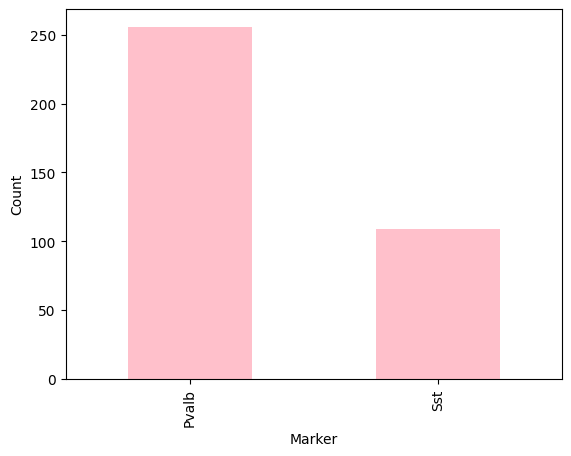

In [3]:
patch_seq['Marker'].value_counts().plot(kind='bar', color='pink')
plt.xlabel('Marker')
plt.ylabel('Count')
plt.show()
#To make each bar into one type of marker, I used the value counts to count the number of pvalb containing neurons and sst containing neurons.
# I then labled each axis.

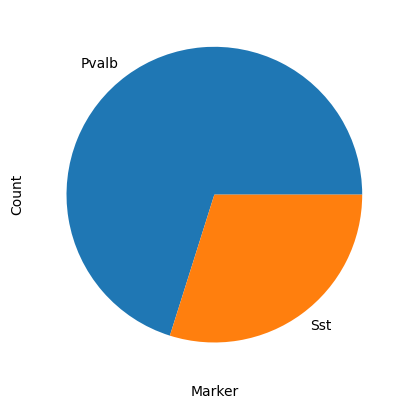

In [4]:
patch_seq['Marker'].value_counts().plot(kind='pie')
plt.xlabel('Marker')
plt.ylabel('Count')
plt.show()
#To make each bar into one type of marker, I used the value counts to count the number of pvalb containing neurons and sst containing neurons.
# I then labled each axis.
#I copied my code from the last cell and changed the type to pie

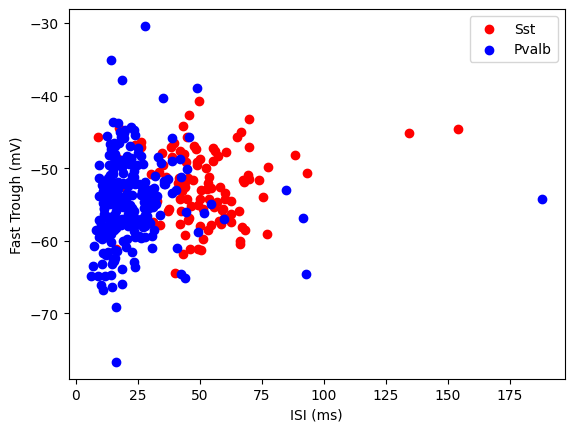

In [5]:
marker_types = patch_seq['Marker'].unique()
#Here I am defining marker types so that my code can differenciate from Pvalb and Sst.

fig = plt.figure()
# Then I am plotting my figure that will then be adjusted

for m_type in marker_types:

    df = patch_seq[patch_seq['Marker'] == m_type]

    if m_type == 'Sst':
      plt.scatter(df['ISI'],
                df['Fast_Trough'],
                label=m_type, color='red')

    if m_type == 'Pvalb':
      plt.scatter(df['ISI'],
                df['Fast_Trough'],
                label=m_type, color='blue')
#Above is my for loop that explains how for each different type of marker the plot should be a different color.

plt.ylabel("Fast Trough (mV)")
plt.xlabel("ISI (ms)")
plt.legend(loc='best')
#I am lableing my axes and making sure it is clear which neronal marker is which color
plt.show()

In [6]:
def patchScatter():
  """
  This is a function that will plot Fast Trough vs ISI where Sst neurons are red and Pvalb neurons are blue.
  """
  marker_types = patch_seq['Marker'].unique()

  fig = plt.figure()

  for m_type in marker_types:

      df = patch_seq[patch_seq['Marker'] == m_type]

      if m_type == 'Sst':
        plt.scatter(df['ISI'],
                  df['Fast_Trough'],
                  label=m_type, color='red')

      if m_type == 'Pvalb':
        plt.scatter(df['ISI'],
                  df['Fast_Trough'],
                  label=m_type, color='blue')


  plt.ylabel("Fast Trough (mV)")
  plt.xlabel("ISI (ms)")
  plt.legend(loc='best')

  plt.show()
#This code cell is making a function that does the same thing as the code cell before it.
#I copied and pasted my code after defining it as a function called patchScatter.

In [7]:
patch_seq.groupby('Marker')['Fast_Trough'].describe()
#This code is to look at the different descriptive statistics like the standard deviation, the number of neurons, and the range (min to max) of these data

,count,mean,std,min,25%,50%,75%,max
Marker,,,,,,,,
Pvalb,256.0,-54.548074,5.870670,-76.687508,-57.914063,-54.490629,-51.364065,-30.406252
Sst,109.0,-52.514968,4.958103,-64.375008,-55.931252,-52.568752,-48.500000,-40.781254


##Difference in the Mean for Sst and Pvalb
The Sst neurons also have a slightly more negative mean fast trough which means it has a more negative undershoot following an action potential. That might also be why the Sst neurons have a larger interspike interval than the Pvalb neurons

In [8]:
patch_seq.groupby('Marker')['Fast_Trough'].skew()
#This code cell is to look at the skewness of the Pvalb vs Sst neurons fast trough.

,Fast_Trough
Marker,
Pvalb,0.19536
Sst,0.00125


##Results of Skewness Test (Fast Trough)
Both Pvalb and Sst neurons have similarly normal distribution. Pvalb neurons have a slightly more positivly skewed distribution, however both Sst and Pvalb are in the range of 0.5 to -0.5. That means the skew is insignificant and they are therefore classified as normally distributed.

In [9]:
patch_seq.groupby('Marker')['ISI'].skew()
#This code cell is to look at the skewness of the Pvalb vs Sst neurons interspike intervals.

,ISI
Marker,
Pvalb,5.596386
Sst,1.857850


##Results of Skewness Test (ISI)
Both Pvalb and Sst neurons have a positivly skewed distribution of interspike intervals. The skewness values are both greater tahn 0.5. The Pvalb neurons have a much more extreme postive skew than the Sst neurons.

In [10]:
sst_neurons = patch_seq[patch_seq['Marker'] == 'Sst']
pvalb_neurons = patch_seq[patch_seq['Marker'] == 'Pvalb']
#Here I am defining sst_neurons and pvalb_neurons so that the t-test can determine which neurons have which markers.

stats.ttest_ind(sst_neurons['Fast_Trough'],pvalb_neurons['Fast_Trough'])
#Now I am running a t-test to look at the difference between pvalb and sst neurons fast trough data.

TtestResult(statistic=np.float64(3.1660773376899147), pvalue=np.float64(0.0016757984214133585), df=np.float64(363.0))

##Results of the t-test (Fast Trough)
The pvalb neurons and the sst neurons have significantly different fast trough values because p<0.05.

In [12]:
sst = sst_neurons['ISI'].dropna()
pvalb = pvalb_neurons['ISI'].dropna()
# I am getting rid of the empty/missing values so that the t-test can be run!

stats.ttest_ind(sst,pvalb)
#Now I am running a t-test to look at the difference between pvalb and sst neurons interspike interval data.

TtestResult(statistic=np.float64(14.643966775010774), pvalue=np.float64(2.694292788633572e-38), df=np.float64(354.0))

##Results of the t-test (ISI)
There is no significant difference in interspike intervals in the pvalb contianing neurons and the sst containing neurons. The p value is greater than 0.05.